# Quais padrões ajudam a investigar fraudes manualmente?

Esta análise usa exclusivamente `output/vrum_timeline_cronologica.csv` para investigar casos de `FRAUDE_CONFIRMADA`. A unidade principal será a proposta de financiamento. Linhas de eventos de risco não serão somadas à base de propostas, evitando dupla contagem.

O objetivo é responder duas perguntas: quais características aparecem nos casos confirmados e o que os sinais históricos permitem avaliar sobre a triagem. A análise não mede produtividade, tempo de fila ou qualidade da decisão humana porque o CSV não contém o registro da revisão manual.

## O arquivo foi lido corretamente?

Antes de interpretar risco, vamos confirmar separador, tipos, datas, tamanho e os principais tipos de evento.

In [1]:
from pathlib import Path
from datetime import timedelta
import matplotlib.pyplot as plt
import polars as pl

COR_PRIMARIA = "#0072B2"
COR_SECUNDARIA = "#94A3B8"
COR_DESTAQUE = "#E69F00"
PALETA = [COR_PRIMARIA, COR_DESTAQUE, "#009E73", "#CC79A7"]
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 110, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

nome_arquivo = "vrum_timeline_cronologica.csv"
candidatos = [Path.cwd().parent / "output" / nome_arquivo, Path.cwd() / "output" / nome_arquivo, Path("/var/home/andpax/Workspace/projetos/vscode-workspace/vrum/output") / nome_arquivo]
caminho = next((p for p in candidatos if p.exists()), None)
if caminho is None:
    raise FileNotFoundError(f"Arquivo não encontrado: {nome_arquivo}")

timeline = pl.read_csv(caminho, separator=";", null_values=[""], try_parse_dates=False, infer_schema_length=10_000)
timeline = timeline.with_columns(pl.col("dt_evento").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False))

print(f"Arquivo: {caminho}")
print(f"Dimensões: {timeline.height:,} linhas x {timeline.width} colunas")
print(f"Período: {timeline["dt_evento"].min()} a {timeline["dt_evento"].max()}")
print(timeline.group_by("tipo_evento").len().sort("len", descending=True))
print(timeline.select(["id_proposta", "dt_evento", "tipo_evento", "valor_financiado", "canal", "marca"]).head(3))

Arquivo: /var/home/andpax/Workspace/projetos/vscode-workspace/vrum/output/vrum_timeline_cronologica.csv
Dimensões: 2,160,408 linhas x 24 colunas
Período: 2026-01-01 00:00:06 a 2026-06-29 20:01:38
shape: (4, 2)
┌─────────────────────────────┬─────────┐
│ tipo_evento                 ┆ len     │
│ ---                         ┆ ---     │
│ str                         ┆ u32     │
╞═════════════════════════════╪═════════╡
│ PROPOSTA_FINANCIAMENTO      ┆ 2129214 │
│ FRAUDE_CONFIRMADA           ┆ 10408   │
│ BUSCA_APREENSAO_INFRUTIFERA ┆ 10403   │
│ NEVER_PAY                   ┆ 10383   │
└─────────────────────────────┴─────────┘
shape: (3, 6)
┌─────────────────┬─────────────────┬────────────────┬────────────────┬────────────────┬───────────┐
│ id_proposta     ┆ dt_evento       ┆ tipo_evento    ┆ valor_financia ┆ canal          ┆ marca     │
│ ---             ┆ ---             ┆ ---            ┆ do             ┆ ---            ┆ ---       │
│ str             ┆ datetime[μs]    ┆ str            

A leitura correta separa uma grande base de propostas dos eventos posteriores de risco. Essa distinção é essencial: o denominador das taxas será a proposta, enquanto fraude, `NEVER_PAY` e apreensão serão desfechos associados.

## Qual é a incidência de fraude em uma janela comparável?

Vamos relacionar cada fraude à proposta original e usar uma janela fixa de 90 dias. Isso evita favorecer propostas antigas, que tiveram mais tempo para apresentar um evento.

In [2]:
propostas = (
    timeline.filter(pl.col("tipo_evento") == "PROPOSTA_FINANCIAMENTO")
    .rename({"dt_evento": "dt_proposta"})
)
eventos = timeline.filter(pl.col("tipo_evento") != "PROPOSTA_FINANCIAMENTO")
fraude_eventos = (
    eventos.filter(pl.col("tipo_evento") == "FRAUDE_CONFIRMADA")
    .group_by("id_proposta")
    .agg(pl.col("dt_evento").min().alias("dt_fraude"))
)

fim_observacao = timeline["dt_evento"].max()
limite_coorte = fim_observacao - timedelta(days=90)
coorte = (
    propostas.filter(pl.col("dt_proposta") <= limite_coorte)
    .join(fraude_eventos, on="id_proposta", how="left")
    .with_columns((pl.col("dt_fraude") - pl.col("dt_proposta")).dt.total_days().alias("dias_ate_fraude"))
    .with_columns((
        pl.col("dt_fraude").is_not_null()
        & (pl.col("dias_ate_fraude") >= 0)
        & (pl.col("dias_ate_fraude") <= 90)
    ).alias("fraude_90d"))
    .with_columns(
        pl.when(pl.col("ltv_proposta") < 1).then(pl.lit("< 1,0"))
        .when(pl.col("ltv_proposta") < 2).then(pl.lit("1,0–2,0"))
        .when(pl.col("ltv_proposta") < 3).then(pl.lit("2,0–3,0"))
        .otherwise(pl.lit(">= 3,0"))
        .alias("ltv_faixa")
    )
)

fraudes_90d = coorte.filter(pl.col("fraude_90d"))
valor_fraude_90d = fraudes_90d.select(pl.col("valor_financiado").sum()).item()
print(f"Corte da coorte: {limite_coorte}")
print(f"Propostas observáveis por 90 dias: {coorte.height:,}")
print(f"Fraudes confirmadas em até 90 dias: {fraudes_90d.height:,}")
print(f"Incidência: {fraudes_90d.height / coorte.height * 100:.3f}%")
print(f"Valor financiado associado: R$ {valor_fraude_90d:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))

Corte da coorte: 2026-03-31 20:01:38
Propostas observáveis por 90 dias: 2,125,751
Fraudes confirmadas em até 90 dias: 10,396
Incidência: 0.489%
Valor financiado associado: R$ 1.121.556.686,23


A coorte reúne 2.125.751 propostas e 10.396 fraudes em até 90 dias, incidência de 0,489% e exposição de aproximadamente R$ 1,122 bilhão. A taxa deve ser interpretada junto do valor: probabilidade e impacto financeiro são perguntas diferentes.

## Quais segmentos têm maior incidência proporcional?

Vamos comparar taxa por mil propostas, mantendo apenas grupos com pelo menos 500 propostas para não transformar amostras pequenas em falsos sinais.

In [3]:
def resumo_dimensao(df, dimensao, minimo=500):
    return (
        df.group_by(dimensao)
        .agg([
            pl.len().alias("propostas"),
            pl.col("fraude_90d").cast(pl.Int8).sum().alias("fraudes"),
            pl.when(pl.col("fraude_90d")).then(pl.col("valor_financiado")).otherwise(0).sum().alias("exposicao_fraude"),
        ])
        .filter(pl.col("propostas") >= minimo)
        .with_columns([
            (pl.col("fraudes") / pl.col("propostas") * 1000).round(2).alias("fraudes_por_mil"),
            (pl.col("exposicao_fraude") / valor_fraude_90d * 100).round(2).alias("share_exposicao_pct"),
        ])
        .sort("fraudes_por_mil", descending=True)
    )

for dimensao in ["canal", "uf_proposta", "marca", "tipo_proponente", "ltv_faixa"]:
    print(f"\n{dimensao}")
    print(resumo_dimensao(coorte, dimensao).head(5))


canal
shape: (3, 6)
┌─────────────────┬───────────┬─────────┬──────────────────┬─────────────────┬─────────────────────┐
│ canal           ┆ propostas ┆ fraudes ┆ exposicao_fraude ┆ fraudes_por_mil ┆ share_exposicao_pct │
│ ---             ┆ ---       ┆ ---     ┆ ---              ┆ ---             ┆ ---                 │
│ str             ┆ u32       ┆ i64     ┆ f64              ┆ f64             ┆ f64                 │
╞═════════════════╪═══════════╪═════════╪══════════════════╪═════════════════╪═════════════════════╡
│ CONCESSIONARIA  ┆ 708176    ┆ 3481    ┆ 3.7024e8         ┆ 4.92            ┆ 33.01               │
│ LOJA_MULTIMARCA ┆ 708326    ┆ 3455    ┆ 3.7738e8         ┆ 4.88            ┆ 33.65               │
│ DIGITAL         ┆ 709249    ┆ 3460    ┆ 3.7394e8         ┆ 4.88            ┆ 33.34               │
└─────────────────┴───────────┴─────────┴──────────────────┴─────────────────┴─────────────────────┘

uf_proposta
shape: (5, 6)
┌─────────────┬───────────┬─────────┬──────

Os canais são muito próximos, entre 4,88 e 4,92 fraudes por mil propostas. A maior diferença exploratória aparece nas faixas de LTV: a faixa `>= 3,0` chega a 5,21 por mil, contra 4,80 na faixa `2,0–3,0`. Isso sugere uma hipótese para investigar, não uma regra pronta.

## Quando a fraude aparece e qual é a exposição mensal?

Vamos observar a evolução dos casos dentro da janela comparável e separar quantidade de casos do valor financiado associado.

shape: (6, 3)
┌─────────┬───────┬───────────┐
│ mes     ┆ casos ┆ exposicao │
│ ---     ┆ ---   ┆ ---       │
│ str     ┆ u32   ┆ f64       │
╞═════════╪═══════╪═══════════╡
│ 2026-01 ┆ 636   ┆ 6.7292e7  │
│ 2026-02 ┆ 1691  ┆ 1.8393e8  │
│ 2026-03 ┆ 3021  ┆ 3.2405e8  │
│ 2026-04 ┆ 2865  ┆ 3.1072e8  │
│ 2026-05 ┆ 1677  ┆ 1.8158e8  │
│ 2026-06 ┆ 506   ┆ 5.3982e7  │
└─────────┴───────┴───────────┘


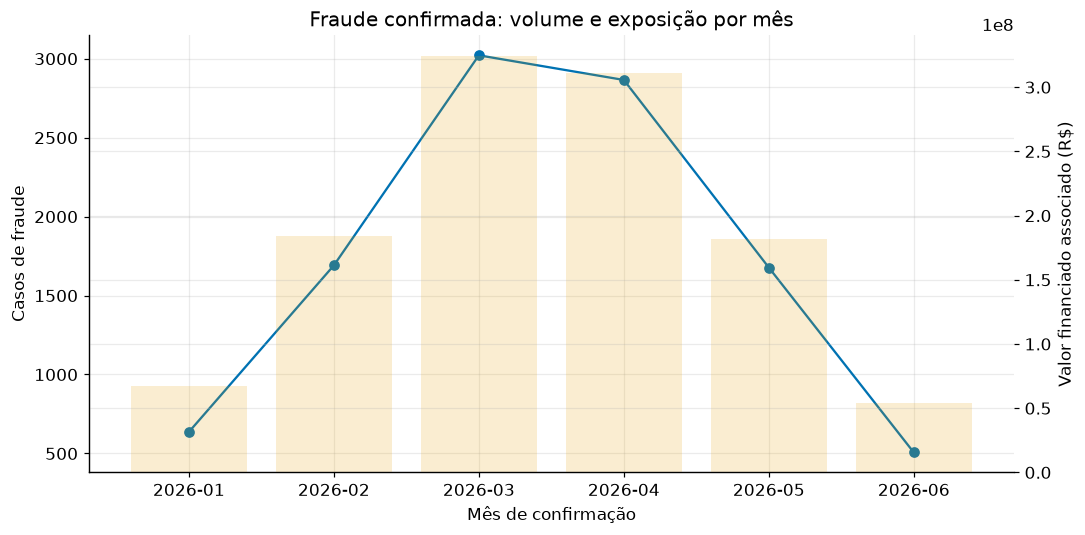

In [4]:
mensal = (
    fraudes_90d.with_columns(pl.col("dt_fraude").dt.strftime("%Y-%m").alias("mes"))
    .group_by("mes")
    .agg([
        pl.len().alias("casos"),
        pl.col("valor_financiado").sum().round(2).alias("exposicao"),
    ])
    .sort("mes")
)
print(mensal)

fig, ax1 = plt.subplots()
meses = mensal["mes"].to_list()
ax1.plot(meses, mensal["casos"].to_list(), marker="o", color=COR_PRIMARIA, label="Casos")
ax1.set_ylabel("Casos de fraude")
ax1.set_xlabel("Mês de confirmação")
ax2 = ax1.twinx()
ax2.bar(meses, mensal["exposicao"].to_list(), alpha=.18, color=COR_DESTAQUE, label="Exposição")
ax2.set_ylabel("Valor financiado associado (R$)")
ax1.set_title("Fraude confirmada: volume e exposição por mês")
fig.tight_layout()
plt.show()

Março concentra o maior volume observado, com 3.021 casos e cerca de R$ 324,1 milhões associados; abril vem em seguida, com 2.865 casos e cerca de R$ 310,7 milhões. O padrão de quantidade e exposição é semelhante nesses dois meses.

## Quanto tempo passa entre a proposta e a confirmação?

O intervalo ajuda a entender se existe uma janela operacional para investigação e se o comportamento varia por canal.

In [5]:
tempo_geral = fraudes_90d.select([
    pl.col("dias_ate_fraude").mean().round(2).alias("media_dias"),
    pl.col("dias_ate_fraude").median().alias("mediana_dias"),
    pl.col("dias_ate_fraude").quantile(0.9).alias("p90_dias"),
    pl.col("dias_ate_fraude").min().alias("min_dias"),
    pl.col("dias_ate_fraude").max().alias("max_dias"),
])
print(tempo_geral)

tempo_canal = (
    fraudes_90d.group_by("canal")
    .agg([
        pl.len().alias("casos"),
        pl.col("dias_ate_fraude").median().alias("mediana_dias"),
        pl.col("dias_ate_fraude").quantile(0.9).alias("p90_dias"),
    ])
    .sort("mediana_dias")
)
print(tempo_canal)

shape: (1, 5)
┌────────────┬──────────────┬──────────┬──────────┬──────────┐
│ media_dias ┆ mediana_dias ┆ p90_dias ┆ min_dias ┆ max_dias │
│ ---        ┆ ---          ┆ ---      ┆ ---      ┆ ---      │
│ f64        ┆ f64          ┆ f64      ┆ i64      ┆ i64      │
╞════════════╪══════════════╪══════════╪══════════╪══════════╡
│ 45.64      ┆ 46.0         ┆ 82.0     ┆ 1        ┆ 90       │
└────────────┴──────────────┴──────────┴──────────┴──────────┘
shape: (3, 4)
┌─────────────────┬───────┬──────────────┬──────────┐
│ canal           ┆ casos ┆ mediana_dias ┆ p90_dias │
│ ---             ┆ ---   ┆ ---          ┆ ---      │
│ str             ┆ u32   ┆ f64          ┆ f64      │
╞═════════════════╪═══════╪══════════════╪══════════╡
│ LOJA_MULTIMARCA ┆ 3455  ┆ 45.0         ┆ 82.0     │
│ CONCESSIONARIA  ┆ 3481  ┆ 46.0         ┆ 82.0     │
│ DIGITAL         ┆ 3460  ┆ 47.0         ┆ 82.0     │
└─────────────────┴───────┴──────────────┴──────────┘


A confirmação ocorre, em média, 45,6 dias após a proposta; a mediana é 46 dias e o P90 é 82 dias. Os canais têm medianas entre 45 e 47 dias, portanto o CSV não indica diferença operacional relevante entre eles. Esse intervalo não representa o tempo de resposta da análise manual.

## Existem sinais de reincidência no mesmo chassi?

Vamos verificar se os casos de fraude aparecem em chassis com mais de uma proposta dentro da coorte. Isso apoia a investigação do histórico, mas não prova que a repetição causou o evento.

In [6]:
chassis = (
    coorte.group_by("chassi_id_sintetico")
    .agg([
        pl.len().alias("propostas"),
        pl.col("fraude_90d").cast(pl.Int8).sum().alias("fraudes"),
        pl.col("valor_financiado").sum().round(2).alias("valor_total"),
    ])
)
print(f"Chassis na coorte: {chassis.height:,}")
print(f"Chassis com mais de uma proposta: {chassis.filter(pl.col('propostas') > 1).height:,}")
print(f"Chassis com fraude e mais de uma proposta: {chassis.filter((pl.col('fraudes') > 0) & (pl.col('propostas') > 1)).height:,}")
reincidencia = (
    coorte.with_columns((pl.col("chassi_id_sintetico").is_duplicated()).alias("chassi_reincidente"))
    .group_by("chassi_reincidente")
    .agg([pl.len().alias("propostas"), pl.col("fraude_90d").cast(pl.Int8).sum().alias("fraudes")])
    .with_columns((pl.col("fraudes") / pl.col("propostas") * 1000).round(2).alias("fraudes_por_mil"))
)
print(reincidencia)
print(chassis.filter(pl.col("fraudes") > 0).sort(["propostas", "valor_total"], descending=True).head(10))

Chassis na coorte: 582,806
Chassis com mais de uma proposta: 521,586
Chassis com fraude e mais de uma proposta: 10,016


shape: (2, 4)
┌────────────────────┬───────────┬─────────┬─────────────────┐
│ chassi_reincidente ┆ propostas ┆ fraudes ┆ fraudes_por_mil │
│ ---                ┆ ---       ┆ ---     ┆ ---             │
│ bool               ┆ u32       ┆ i64     ┆ f64             │
╞════════════════════╪═══════════╪═════════╪═════════════════╡
│ false              ┆ 61220     ┆ 286     ┆ 4.67            │
│ true               ┆ 2064531   ┆ 10110   ┆ 4.9             │
└────────────────────┴───────────┴─────────┴─────────────────┘
shape: (10, 4)
┌──────────────────────┬───────────┬─────────┬─────────────┐
│ chassi_id_sintetico  ┆ propostas ┆ fraudes ┆ valor_total │
│ ---                  ┆ ---       ┆ ---     ┆ ---         │
│ str                  ┆ u32       ┆ i64     ┆ f64         │
╞══════════════════════╪═══════════╪═════════╪═════════════╡
│ CHASSI_SYN_000565041 ┆ 13        ┆ 1       ┆ 1.7163e6    │
│ CHASSI_SYN_000506130 ┆ 13        ┆ 1       ┆ 1.4836e6    │
│ CHASSI_SYN_000349211 ┆ 13        ┆ 1  

A repetição de chassi é muito comum na base: 521.586 dos 582.806 chassis têm mais de uma proposta. A incidência é parecida entre chassis reincidentes e não reincidentes, 4,90 contra 4,67 fraudes por mil; portanto, apenas encontrar repetição não basta para priorizar um caso.

## A marcação histórica de risco aparece nos casos de fraude?

Vamos comparar `evento_risco_chassi_90d` entre propostas com e sem fraude na janela. O resultado será tratado como associação histórica, porque ainda não sabemos se esse campo estava disponível antes do evento.

In [7]:
sinal = (
    coorte.with_columns((pl.col("evento_risco_chassi_90d") == 1).alias("marcado_risco"))
    .group_by("marcado_risco")
    .agg([
        pl.len().alias("propostas"),
        pl.col("fraude_90d").cast(pl.Int8).sum().alias("fraudes"),
    ])
    .with_columns((pl.col("fraudes") / pl.col("propostas") * 100).round(3).alias("taxa_fraude_pct"))
    .sort("marcado_risco")
)
print(sinal)
print("\nSem registro temporal de disponibilidade do campo, esta tabela não mede precisão preditiva.")

shape: (2, 4)
┌───────────────┬───────────┬─────────┬─────────────────┐
│ marcado_risco ┆ propostas ┆ fraudes ┆ taxa_fraude_pct │
│ ---           ┆ ---       ┆ ---     ┆ ---             │
│ bool          ┆ u32       ┆ i64     ┆ f64             │
╞═══════════════╪═══════════╪═════════╪═════════════════╡
│ false         ┆ 2094605   ┆ 0       ┆ 0.0             │
│ true          ┆ 31146     ┆ 10396   ┆ 33.378          │
└───────────────┴───────────┴─────────┴─────────────────┘

Sem registro temporal de disponibilidade do campo, esta tabela não mede precisão preditiva.


## O que o CSV permite concluir?

A análise mostra incidência de 0,489% na coorte de 90 dias, canais muito equilibrados, uma diferença exploratória maior nas faixas de LTV e confirmação típica em 46 dias. A reincidência por chassi, isoladamente, diferencia pouco.

A marcação `evento_risco_chassi_90d` aparece em 31.146 propostas e concentra todas as 10.396 fraudes da coorte. Esse resultado sugere que o campo pode conter o próprio desfecho ou informação posterior; ele não deve ser usado como evidência de eficácia preditiva sem validação temporal.

Ela não permite medir tempo de fila, produtividade do analista, falso positivo, precisão da decisão ou ganho operacional da triagem. Para isso, seria necessário registrar a entrada na análise manual, decisão, motivo, data de saída e resultado da revisão.

O próximo uso recomendado é transformar os segmentos com maior taxa e maior exposição em uma lista de investigação, mantendo volume mínimo e validação temporal antes de propor qualquer regra operacional.